In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configure plotting style
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10
%matplotlib inline

# Create vizualizations folder if it doesn't exist
import os
if not os.path.exists("../visualizations_pre_imputation"):
    os.makedirs("../visualizations_pre_imputation")

# NHANES Hypertension Risk — Data Exploration

Comprehensive data visualizations exploring the relationship between demographics, clinical measurements, and hypertension risk in a nationally representative sample of U.S. adults.

In [2]:
# Load the dataset
df = pd.read_csv('../data/nhanes_hypertension_risk_pre_imputation.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nBasic statistics:\n{df.describe()}")

Dataset shape: (3562, 40)

Columns: ['participant_id', 'age', 'race_ethnicity', 'education', 'poverty_income_ratio', 'marital_status', 'diagnosed_high_bp', 'diagnosed_twice', 'on_chol_medication', 'on_bp_medication', 'bmi', 'waist_cm', 'weight_kg', 'height_cm', 'smoked_100_cigarettes', 'smoke_frequency', 'avg_drinks_per_day', 'time_sitting', 'total_cholesterol_mgdl', 'HDL_cholesterol_mgdl', 'fasting_glucose_mgdl', 'LDL_cholesterol_mgdl_friedewald', 'LDL_cholesterol_mgdl_martin', 'LDL_cholesterol_mgdl_nih', 'systolic_avg', 'systolic_clinical', 'diastolic_avg', 'diastolic_clinical', 'pulse_avg', 'pulse_clinical', 'hypertension_risk', 'male', 'ever_smoker', 'current_smoker', 'drinks_alcohol', 'drink_frequency_past_year', 'high_cholesterol', 'moderate_minutes_per_week', 'vigorous_minutes_per_week', 'physically_active']

Basic statistics:
       participant_id          age  poverty_income_ratio  diagnosed_high_bp  \
count     3562.000000  3520.000000          3.083000e+03        3560.000000

In [3]:
# Create human-readable sex labels
df['sex_label'] = df['male'].map({1.0: 'Male', 0.0: 'Female'})

# Create age groups for analysis
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 40, 50, 60, 100], 
                         labels=['18-30', '31-40', '41-50', '51-60', '60+'])

# Create BP category based on clinical readings
df['bp_category'] = 'Normal'
df.loc[(df['systolic_clinical'] >= 130) | (df['diastolic_clinical'] >= 80), 'bp_category'] = 'Elevated'
df.loc[(df['systolic_clinical'] >= 140) | (df['diastolic_clinical'] >= 90), 'bp_category'] = 'High'

print("New features created:")
print(f"  - sex_label: {df['sex_label'].value_counts().to_dict()}")
print(f"  - age_group: {df['age_group'].value_counts().sort_index().to_dict()}")
print(f"  - bp_category: {df['bp_category'].value_counts().to_dict()}")

New features created:
  - sex_label: {'Female': 1959, 'Male': 1603}
  - age_group: {'18-30': 547, '31-40': 499, '41-50': 439, '51-60': 558, '60+': 1477}
  - bp_category: {'Normal': 2237, 'Elevated': 742, 'High': 583}


## 2. Hypertension Risk by Gender and Age Group

This visualization shows how hypertension risk varies across different age groups and genders.

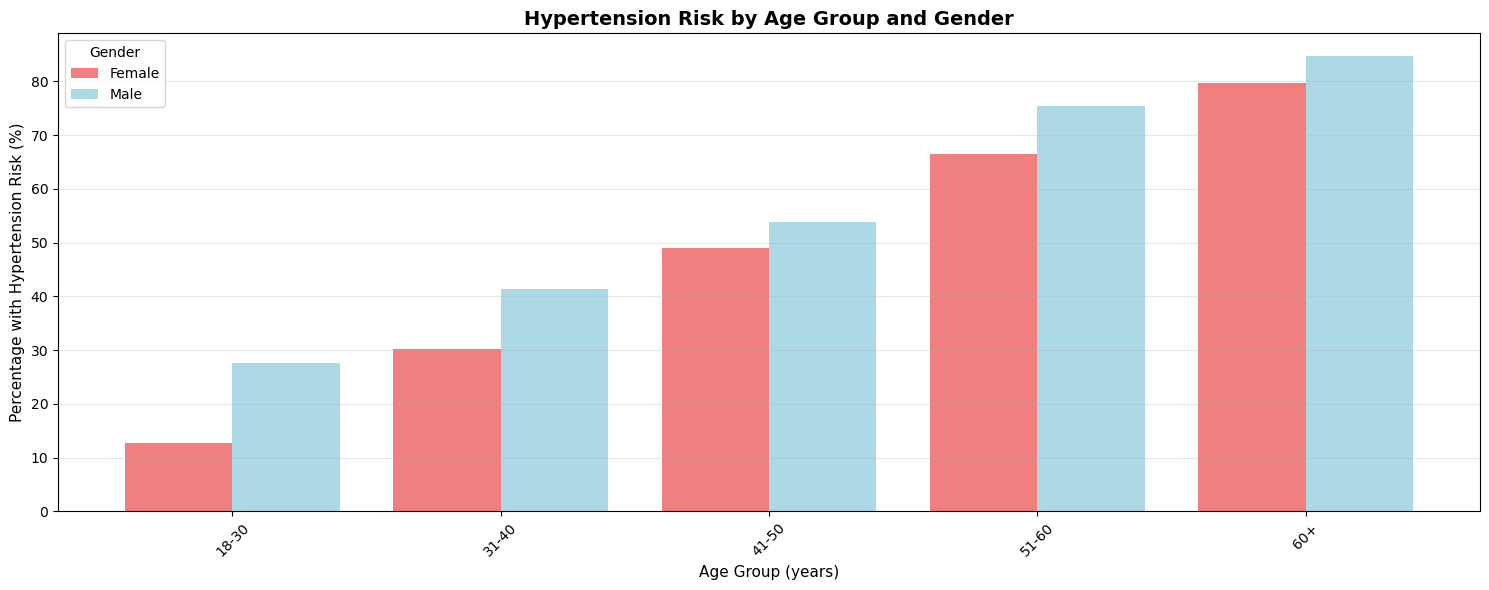


Hypertension Risk Breakdown:
age_group  sex_label
18-30      Female       12.666667
           Male         27.530364
31-40      Female       30.240550
           Male         41.346154
41-50      Female       49.019608
           Male         53.804348
51-60      Female       66.445183
           Male         75.486381
60+        Female       79.617834
           Male         84.682081
Name: hypertension_risk, dtype: float64


In [4]:
# Create a crosstab for hypertension risk by age and gender
risk_by_age_sex = pd.crosstab(
    [df['age_group'], df['sex_label']], 
    df['hypertension_risk'], 
    normalize='index'
) * 100

fig, axes = plt.subplots(figsize=(15, 6))

# Grouped bar chart: Hypertension risk by age and gender
risk_by_age_gender = df.groupby(['age_group', 'sex_label'])['hypertension_risk'].mean() * 100
risk_by_age_gender.unstack().plot(kind='bar', ax=axes, width=0.8, color=['lightcoral', 'lightblue'])
axes.set_title('Hypertension Risk by Age Group and Gender', fontsize=14, fontweight='bold')
axes.set_xlabel('Age Group (years)', fontsize=11)
axes.set_ylabel('Percentage with Hypertension Risk (%)', fontsize=11)
axes.set_xticklabels(axes.get_xticklabels(), rotation=45)
axes.legend(title='Gender', frameon=True)
axes.grid(axis='y', alpha=0.3)

# save the figure to visualizations folder
plt.savefig("../visualizations_pre_imputation/2_hypertension_risk_by_age_gender.png", dpi=300, bbox_inches='tight')

# display the figure
plt.tight_layout()
plt.show()

print("\nHypertension Risk Breakdown:")
print(risk_by_age_gender)

## 3. Blood Pressure Elevation and Diagnosis Status by Race

Among individuals with elevated blood pressure (systolic ≥130 OR diastolic ≥80), what percentage have been previously diagnosed with high blood pressure?

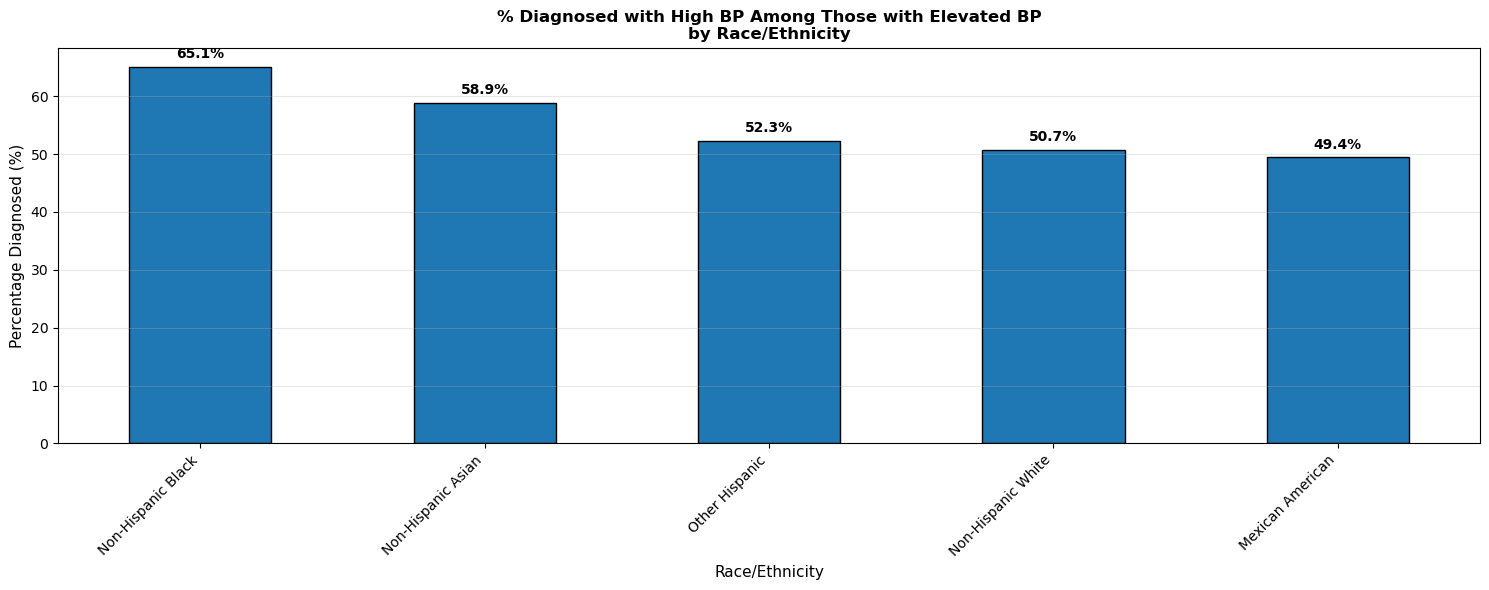


Diagnosis Rate for Individuals with Elevated BP by Race/Ethnicity:
                    Total with Elevated BP  Diagnosed  % Diagnosed
race_ethnicity                                                    
Non-Hispanic Black                     195        127    65.128205
Non-Hispanic Asian                      73         43    58.904110
Other Hispanic                         109         57    52.293578
Non-Hispanic White                     771        391    50.713359
Mexican American                        89         44    49.438202


In [5]:
# Filter to those with elevated BP
elevated_bp = df[(df['systolic_clinical'] >= 130) | (df['diastolic_clinical'] >= 80)].copy()
elevated_bp['diagnosed'] = elevated_bp['diagnosed_high_bp'].isin([1.0])  # 1 = diagnosed

# Calculate diagnosis rate by race for those with elevated BP
diagnosis_by_race = elevated_bp.groupby('race_ethnicity')['diagnosed'].agg(['sum', 'count'])
diagnosis_by_race['percent_diagnosed'] = (diagnosis_by_race['sum'] / diagnosis_by_race['count']) * 100
diagnosis_by_race = diagnosis_by_race.sort_values('percent_diagnosed', ascending=False)

fig, axes = plt.subplots(figsize=(15, 6))

# Bar chart: Diagnosis rate by race
diagnosis_by_race['percent_diagnosed'].plot(kind='bar', ax=axes, edgecolor='black')
axes.set_title('% Diagnosed with High BP Among Those with Elevated BP\nby Race/Ethnicity', 
                   fontsize=12, fontweight='bold')
axes.set_xlabel('Race/Ethnicity', fontsize=11)
axes.set_ylabel('Percentage Diagnosed (%)', fontsize=11)
axes.set_xticklabels(axes.get_xticklabels(), rotation=45, ha='right')
axes.grid(axis='y', alpha=0.3)
for i, v in enumerate(diagnosis_by_race['percent_diagnosed'].values):
    axes.text(i, v + 1.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)
# save the figure to visualizations folder
plt.savefig("../visualizations_pre_imputation/3_diagnosis_rate_by_race.png", dpi=300, bbox_inches='tight')

# display the figure
plt.tight_layout()
plt.show()

print("\nDiagnosis Rate for Individuals with Elevated BP by Race/Ethnicity:")
print(diagnosis_by_race[['count', 'sum', 'percent_diagnosed']].rename(
    columns={'count': 'Total with Elevated BP', 'sum': 'Diagnosed', 'percent_diagnosed': '% Diagnosed'}
))

## 4. Blood Pressure Elevation and Diagnosis Status by Poverty Income Ratio


Among individuals with elevated blood pressure (systolic ≥130 OR diastolic 
≥80), how does diagnosis status change as the poverty income ratio increases?

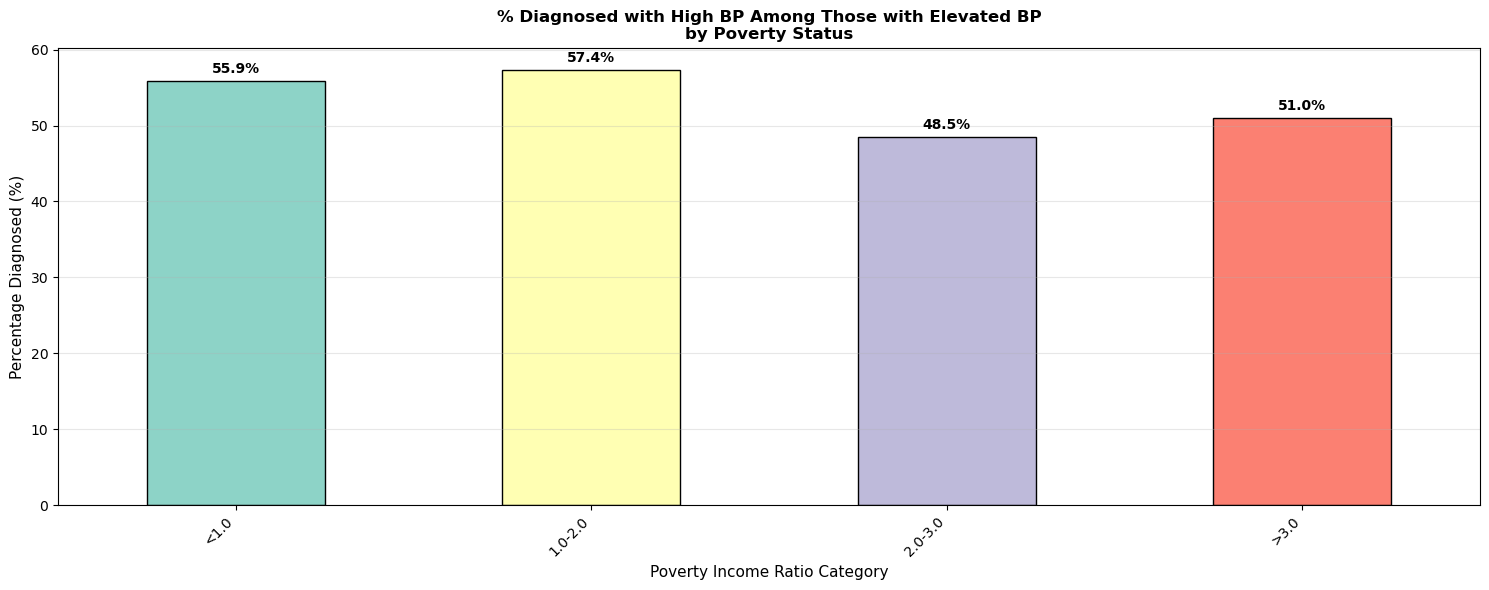


Diagnosis Rate for Individuals with Elevated BP by Poverty Level:
                  Total with Elevated BP  Diagnosed  % Diagnosed
poverty_category                                                
<1.0                                 170         95    55.882353
1.0-2.0                              237        136    57.383966
2.0-3.0                              206        100    48.543689
>3.0                                 545        278    51.009174


In [6]:
# Filter to those with elevated BP
elevated_bp = df[(df['systolic_clinical'] >= 130) | (df['diastolic_clinical'] 
>= 80)].copy()
elevated_bp['diagnosed'] = elevated_bp['diagnosed_high_bp'].isin([1.0])  # 1 = diagnosed


# Calculate diagnosis rate by poverty status for those with elevated BP
# bin poverty_income_ratio into categories
elevated_bp['poverty_category'] = pd.cut(elevated_bp['poverty_income_ratio'], 
                                         bins=[-np.inf, 1.0, 2.0, 3.0, np.inf], 
                                         labels=['<1.0', '1.0-2.0', '2.0-3.0', '>3.0'])
diagnosis_by_poverty = elevated_bp.groupby('poverty_category')['diagnosed'].agg(['sum', 'count'])
diagnosis_by_poverty['percent_diagnosed'] = (diagnosis_by_poverty['sum'] / 
diagnosis_by_poverty['count']) * 100

fig, axes = plt.subplots(figsize=(15, 6))

# Bar chart: Diagnosis rate by poverty status
poverty_colors = sns.color_palette('Set3', len(diagnosis_by_poverty))
diagnosis_by_poverty['percent_diagnosed'].plot(kind='bar', ax=axes, color=poverty_colors, edgecolor='black')
axes.set_title('% Diagnosed with High BP Among Those with Elevated BP\nby Poverty Status', 
                   fontsize=12, fontweight='bold')
axes.set_xlabel('Poverty Income Ratio Category', fontsize=11)
axes.set_ylabel('Percentage Diagnosed (%)', fontsize=11)
axes.set_xticklabels(axes.get_xticklabels(), rotation=45, ha='right')
axes.grid(axis='y', alpha=0.3)
for i, v in enumerate(diagnosis_by_poverty['percent_diagnosed'].values):
    axes.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)

# save the figure to visualizations folder
plt.savefig("../visualizations_pre_imputation/4_diagnosis_rate_by_poverty.png", dpi=300, bbox_inches='tight')

# display the figure
plt.tight_layout()
plt.show()


print("\nDiagnosis Rate for Individuals with Elevated BP by Poverty Level:")
print(diagnosis_by_poverty[['count', 'sum', 'percent_diagnosed']].rename(
    columns={'count': 'Total with Elevated BP', 'sum': 'Diagnosed', 
'percent_diagnosed': '% Diagnosed'}
))

## 5. Violin Plots — Blood Pressure by Demographics

Kernel density estimates showing BP distributions across demographic groups.

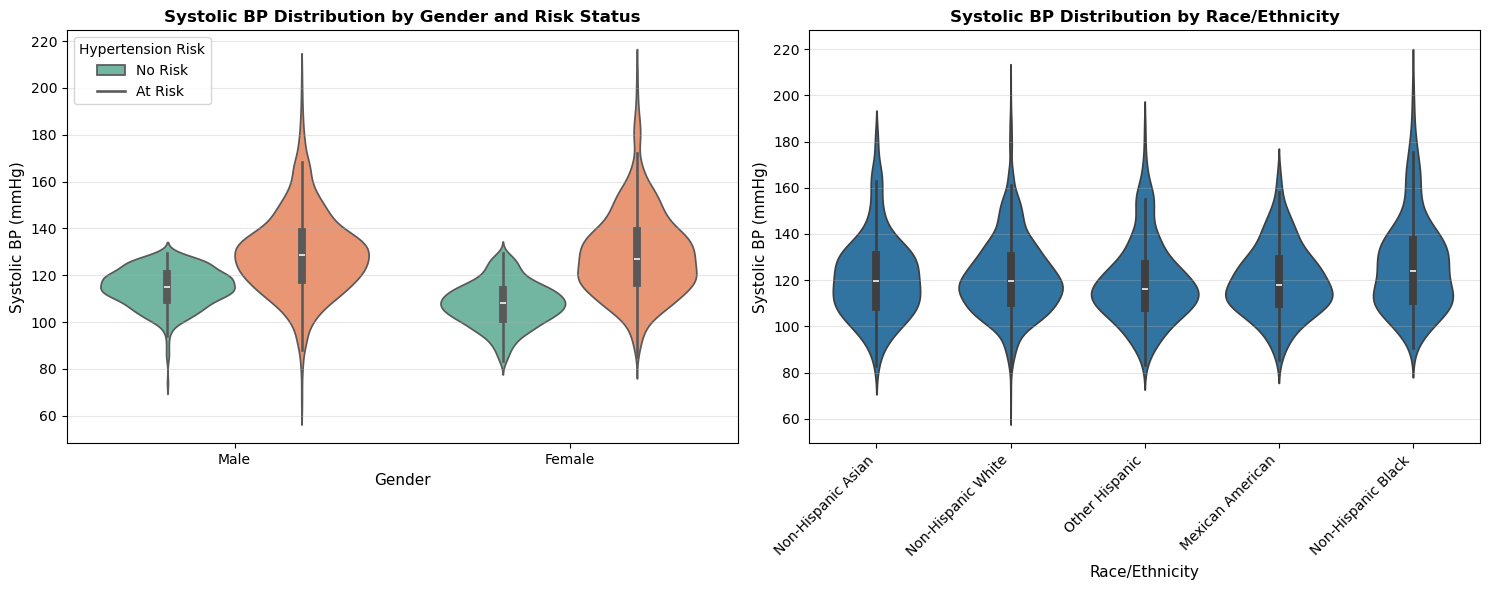

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Systolic BP by gender and hypertension risk
sns.violinplot(data=df, x='sex_label', y='systolic_clinical', hue='hypertension_risk', ax=axes[0], palette ='Set2', split=False)
axes[0].set_title('Systolic BP Distribution by Gender and Risk Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=11)
axes[0].set_ylabel('Systolic BP (mmHg)', fontsize=11)
axes[0].legend(title='Hypertension Risk', labels=['No Risk', 'At Risk'])
axes[0].grid(axis='y', alpha=0.3)

# Systolic BP by race
sns.violinplot(data=df, x='race_ethnicity', y='systolic_clinical', ax=axes[1])
axes[1].set_title('Systolic BP Distribution by Race/Ethnicity', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Race/Ethnicity', fontsize=11)
axes[1].set_ylabel('Systolic BP (mmHg)', fontsize=11)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

# save the figure to visualizations folder
plt.savefig("../visualizations_pre_imputation/5_systolic_bp_distributions.png", dpi=300, bbox_inches='tight')

# display the figure
plt.tight_layout()
plt.show()

## 6. Q-Q Plots — Normality Assessment

Quantile-Quantile plots to assess if blood pressure measurements follow a normal distribution.

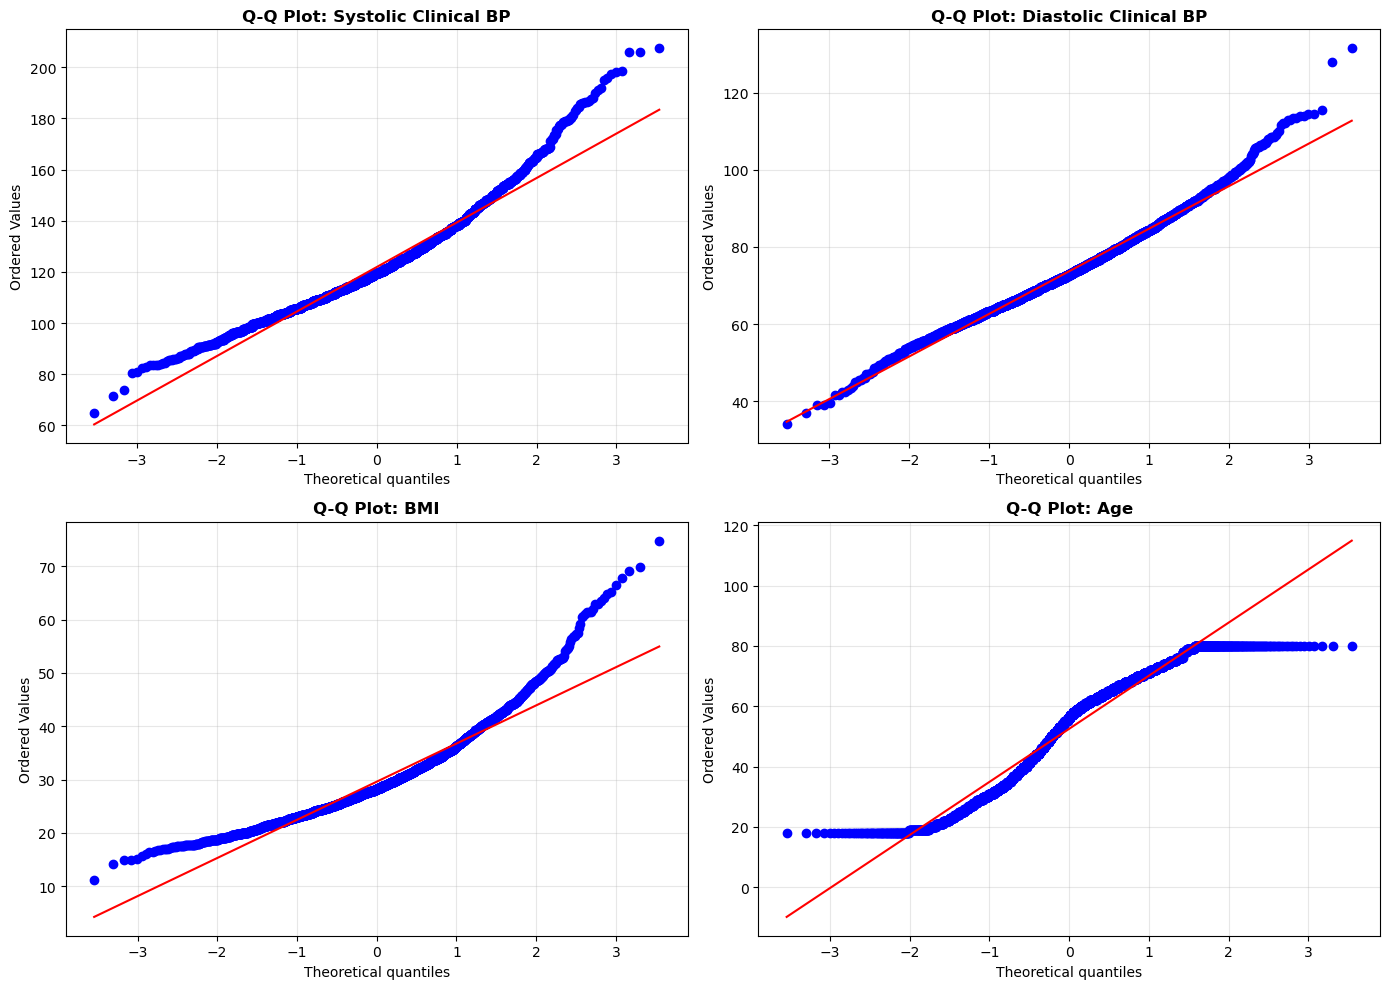

Normality Test (Shapiro-Wilk test, p > 0.05 suggests normality):
  Systolic BP:  W=0.9603, p=1.4226e-29
  Diastolic BP: W=0.9877, p=1.6495e-16
  BMI:         W=0.9270, p=2.4173e-38
  Age:         W=0.9483, p=1.6188e-33


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Q-Q plot for systolic clinical
stats.probplot(df['systolic_clinical'].dropna(), dist='norm', plot=axes[0, 0])
axes[0, 0].set_title('Q-Q Plot: Systolic Clinical BP', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Q-Q plot for diastolic clinical
stats.probplot(df['diastolic_clinical'].dropna(), dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot: Diastolic Clinical BP', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Q-Q plot for BMI
stats.probplot(df['bmi'].dropna(), dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot: BMI', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Q-Q plot for age
stats.probplot(df['age'].dropna(), dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot: Age', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

# save the figure to visualizations folder
plt.savefig("../visualizations_pre_imputation/6_qq_plots.png", dpi=300, bbox_inches='tight')

# display the figure
plt.tight_layout()
plt.show()

print("Normality Test (Shapiro-Wilk test, p > 0.05 suggests normality):")
print(f"  Systolic BP:  W={stats.shapiro(df['systolic_clinical'].dropna())[0]:.4f}, p={stats.shapiro(df['systolic_clinical'].dropna())[1]:.4e}")
print(f"  Diastolic BP: W={stats.shapiro(df['diastolic_clinical'].dropna())[0]:.4f}, p={stats.shapiro(df['diastolic_clinical'].dropna())[1]:.4e}")
print(f"  BMI:         W={stats.shapiro(df['bmi'].dropna())[0]:.4f}, p={stats.shapiro(df['bmi'].dropna())[1]:.4e}")
print(f"  Age:         W={stats.shapiro(df['age'].dropna())[0]:.4f}, p={stats.shapiro(df['age'].dropna())[1]:.4e}")

## 7. Body Composition and Health Metrics by Risk Status

BMI, waist circumference, and other body composition measures stratified by hypertension risk.

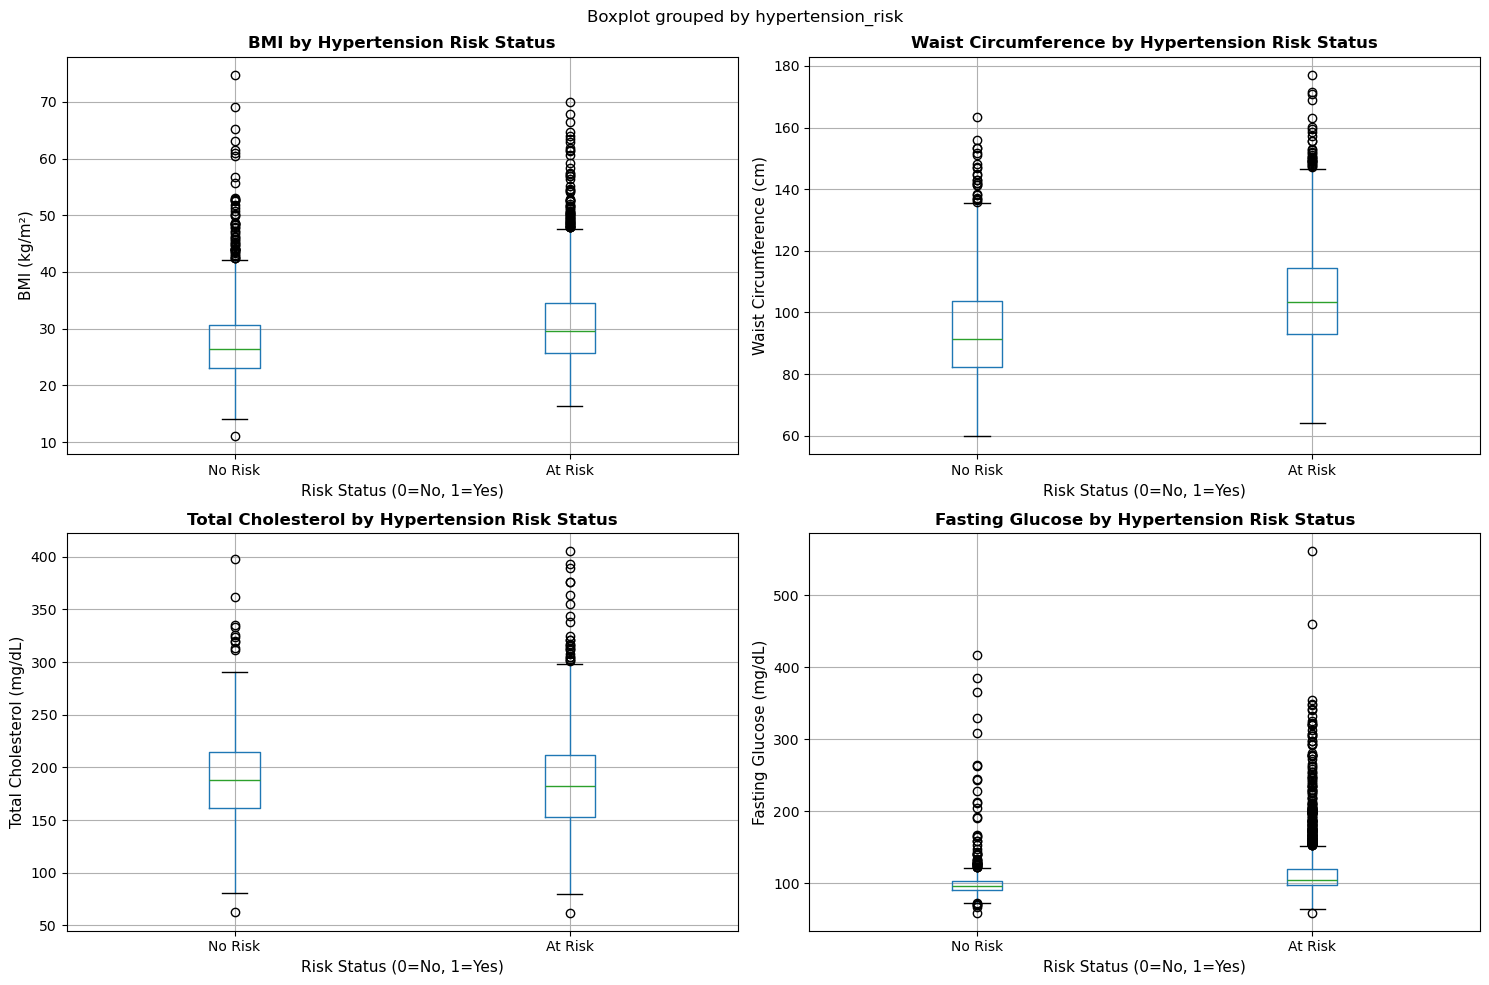


Body Composition and Health Metrics by Risk Status:
                      bmi                                                      \
                    count       mean       std   min   25%   50%    75%   max   
hypertension_risk                                                               
0                  1397.0  27.644023  7.061307  11.1  23.0  26.4  30.70  74.8   
1                  2115.0  30.873664  7.386333  16.4  25.7  29.5  34.45  69.9   

                  waist_cm              ... total_cholesterol_mgdl         \
                     count        mean  ...                    75%    max   
hypertension_risk                       ...                                 
0                   1333.0   93.817404  ...                  215.0  398.0   
1                   2029.0  104.708526  ...                  212.0  405.0   

                  fasting_glucose_mgdl                                     \
                                 count        mean        std   min   25%   
h

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# BMI distribution by risk status
df.boxplot(column='bmi', by='hypertension_risk', ax=axes[0, 0])
axes[0, 0].set_title('BMI by Hypertension Risk Status', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Risk Status (0=No, 1=Yes)', fontsize=11)
axes[0, 0].set_ylabel('BMI (kg/m²)', fontsize=11)
plt.sca(axes[0, 0])
plt.xticks([1, 2], ['No Risk', 'At Risk'])

# Waist circumference by risk status
df.boxplot(column='waist_cm', by='hypertension_risk', ax=axes[0, 1])
axes[0, 1].set_title('Waist Circumference by Hypertension Risk Status', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Risk Status (0=No, 1=Yes)', fontsize=11)
axes[0, 1].set_ylabel('Waist Circumference (cm)', fontsize=11)
plt.sca(axes[0, 1])
plt.xticks([1, 2], ['No Risk', 'At Risk'])

# Cholesterol levels by risk status
df.boxplot(column='total_cholesterol_mgdl', by='hypertension_risk', ax=axes[1, 0])
axes[1, 0].set_title('Total Cholesterol by Hypertension Risk Status', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Risk Status (0=No, 1=Yes)', fontsize=11)
axes[1, 0].set_ylabel('Total Cholesterol (mg/dL)', fontsize=11)
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['No Risk', 'At Risk'])

# Fasting glucose by risk status
df.boxplot(column='fasting_glucose_mgdl', by='hypertension_risk', ax=axes[1, 1])
axes[1, 1].set_title('Fasting Glucose by Hypertension Risk Status', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Risk Status (0=No, 1=Yes)', fontsize=11)
axes[1, 1].set_ylabel('Fasting Glucose (mg/dL)', fontsize=11)
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['No Risk', 'At Risk'])

# save the figure to visualizations folder
plt.savefig("../visualizations_pre_imputation/7_body_composition_by_risk.png", dpi=300, bbox_inches='tight')

# display the figure
plt.tight_layout()
plt.show()

print("\nBody Composition and Health Metrics by Risk Status:")
summary_stats = df.groupby('hypertension_risk')[['bmi', 'waist_cm', 'total_cholesterol_mgdl', 'fasting_glucose_mgdl']].describe()
print(summary_stats)

## 8. Age and Demographic Distribution

Overview of age distribution and demographic composition of the study sample.

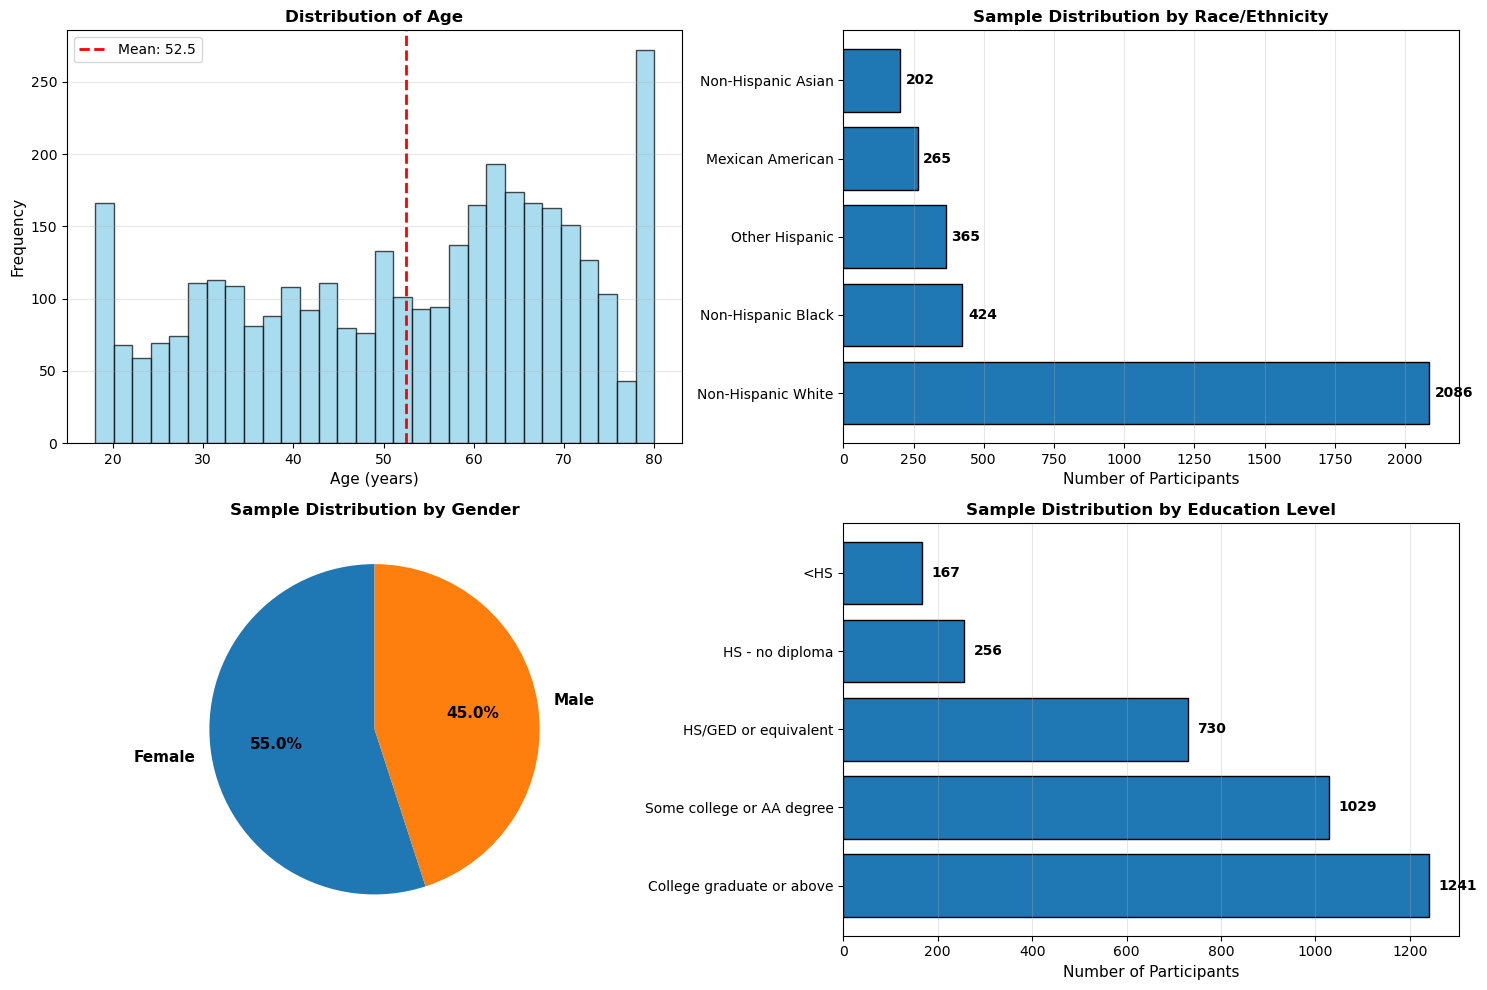


Demographic Summary:

Gender Distribution:
sex_label
Female    1959
Male      1603
Name: count, dtype: int64

Race/Ethnicity Distribution:
race_ethnicity
Non-Hispanic White    2086
Non-Hispanic Black     424
Other Hispanic         365
Mexican American       265
Non-Hispanic Asian     202
Name: count, dtype: int64

Education Distribution:
education
College graduate or above    1241
Some college or AA degree    1029
HS/GED or equivalent          730
HS - no diploma               256
<HS                           167
Name: count, dtype: int64


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age histogram
axes[0, 0].hist(df['age'].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["age"].mean():.1f}')
axes[0, 0].set_title('Distribution of Age', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age (years)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Race/ethnicity distribution
race_counts = df['race_ethnicity'].value_counts()
# colors_race = sns.color_palette('Set3', len(race_counts))
axes[0, 1].barh(race_counts.index, race_counts.values, edgecolor='black')
axes[0, 1].set_title('Sample Distribution by Race/Ethnicity', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Number of Participants', fontsize=11)
axes[0, 1].grid(axis='x', alpha=0.3)
for i, v in enumerate(race_counts.values):
    axes[0, 1].text(v + 20, i, str(v), va='center', fontweight='bold')

# Gender distribution
gender_counts = df['sex_label'].value_counts()
# colors_gender = ['#1f77b4', '#ff7f0e']
axes[1, 0].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
axes[1, 0].set_title('Sample Distribution by Gender', fontsize=12, fontweight='bold')

# Education level
education_counts = df['education'].value_counts()
axes[1, 1].barh(education_counts.index, education_counts.values, edgecolor='black')
axes[1, 1].set_title('Sample Distribution by Education Level', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Number of Participants', fontsize=11)
axes[1, 1].grid(axis='x', alpha=0.3)
for i, v in enumerate(education_counts.values):
    axes[1, 1].text(v + 20, i, str(v), va='center', fontweight='bold')

# save the figure to visualizations folder
plt.savefig("../visualizations_pre_imputation/8_demographic_summary.png", dpi=300, bbox_inches='tight')

# display the figure
plt.tight_layout()
plt.show()

print(f"\nDemographic Summary:")
print(f"\nGender Distribution:\n{gender_counts}")
print(f"\nRace/Ethnicity Distribution:\n{race_counts}")
print(f"\nEducation Distribution:\n{education_counts}")

## 9. Physical Activity and Lifestyle Factors

Distribution of physical activity and behavioral risk factors.

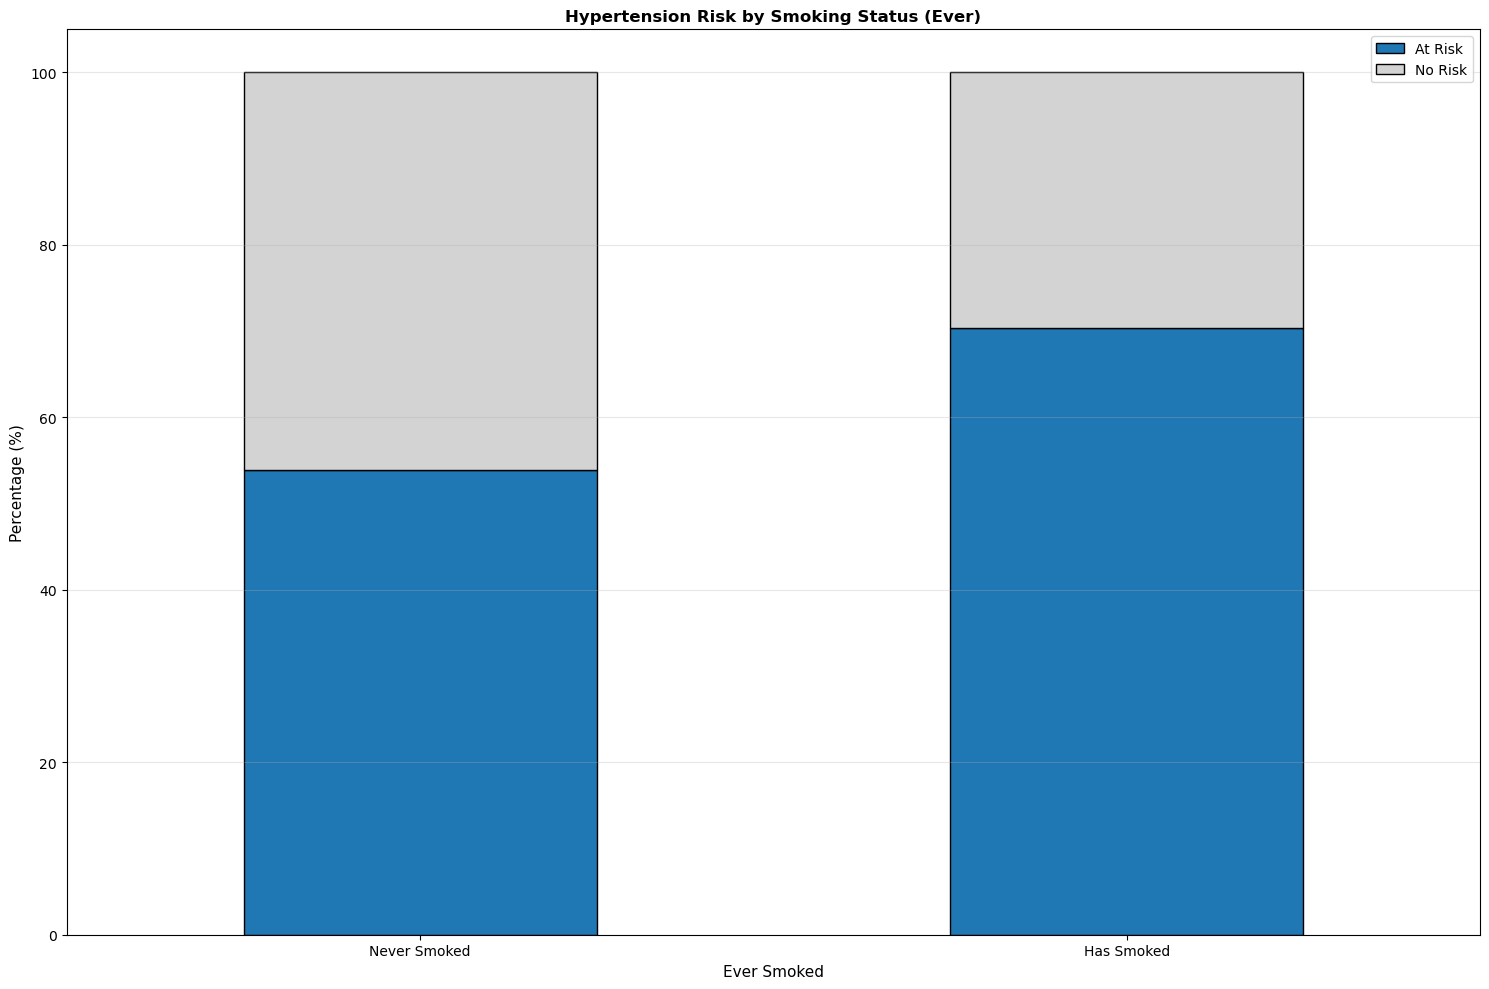


Smoking Summary:
hypertension_risk          0          1
ever_smoker                            
0.0                46.129180  53.870820
1.0                29.621543  70.378457

Ever Smoker Distribution: {0.0: 2183, 1.0: 1374}


In [11]:
fig, axes = plt.subplots(figsize=(15, 10))

# Smoking status
ever_smoking_risk = df.groupby('ever_smoker')['hypertension_risk'].value_counts().unstack(fill_value=0)
ever_smokes_pct = ever_smoking_risk.div(ever_smoking_risk.sum(axis=1), axis=0) * 100
ever_smokes_pct[[1,0]].plot(kind='bar', stacked=True, ax=axes, edgecolor='black', 
color=['C0','lightgray'])
axes.set_title('Hypertension Risk by Smoking Status (Ever)', fontsize=12, fontweight='bold')
axes.set_xlabel('Ever Smoked', fontsize=11)
axes.set_ylabel('Percentage (%)', fontsize=11)
axes.set_xticklabels(["Never Smoked", "Has Smoked"], rotation=0)
axes.legend(['At Risk','No Risk'], frameon=True)
axes.grid(axis='y', alpha=0.3)

# Save figure to the visualizations folder
plt.savefig("../visualizations_pre_imputation/9a_ever_smoking_status.png", dpi=300, bbox_inches='tight')

# Display the figure
plt.tight_layout()
plt.show()

print("\nSmoking Summary:")
print(ever_smokes_pct)
print(f"\nEver Smoker Distribution: {df['ever_smoker'].value_counts().to_dict()}")

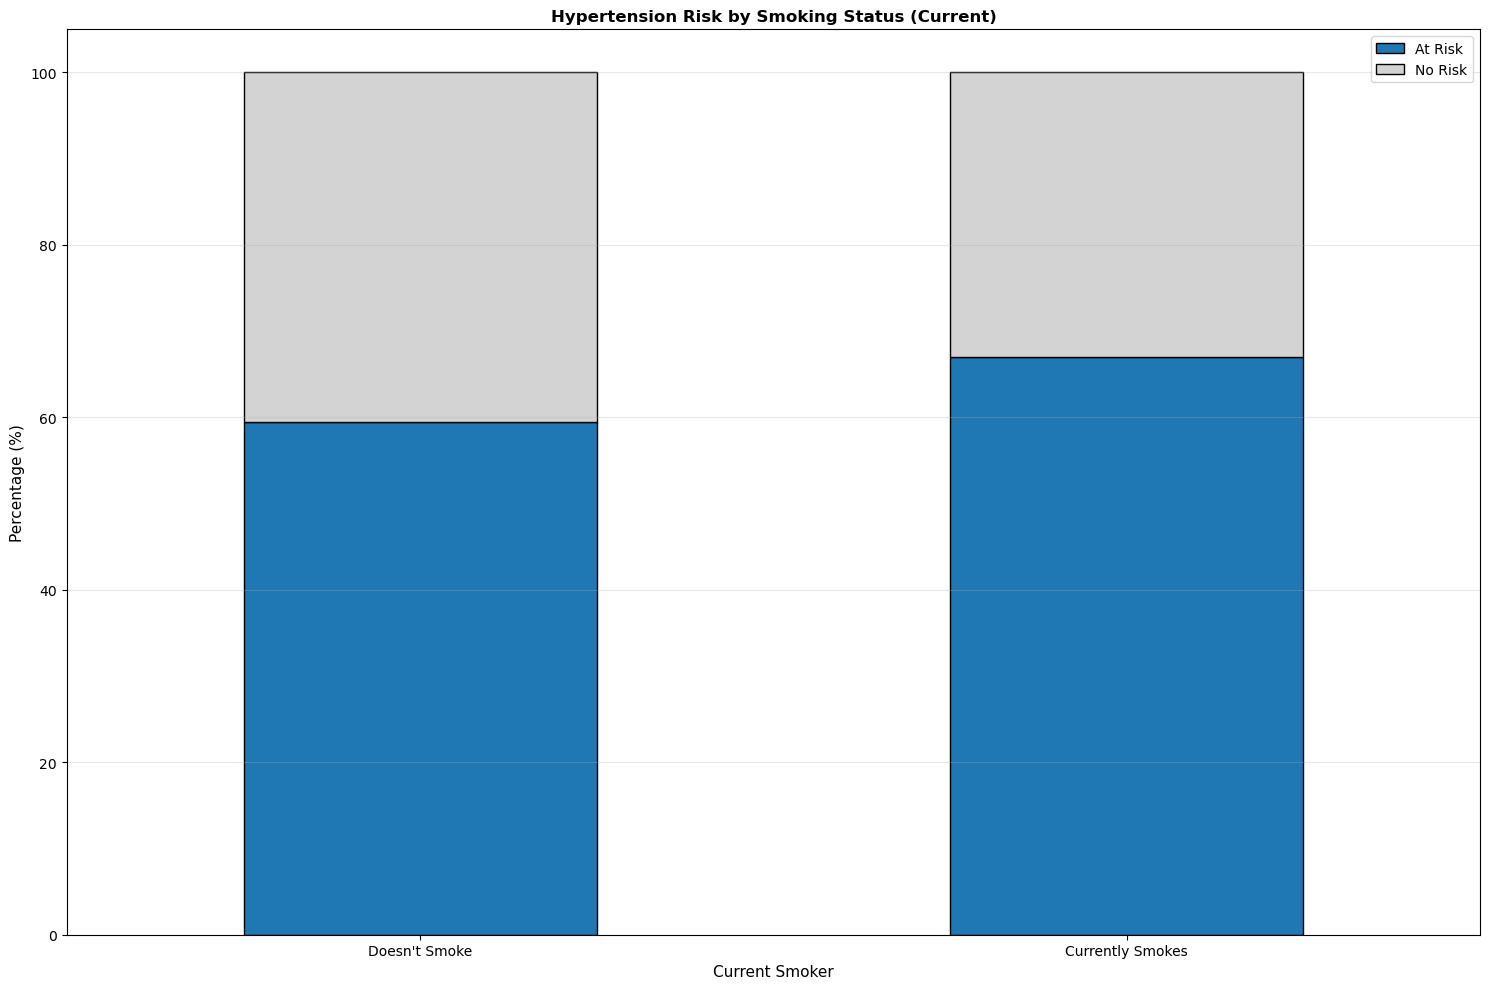


Smoking Summary:
hypertension_risk          0          1
current_smoker                         
0                  40.537164  59.462836
1                  33.055556  66.944444

Current Smoker Distribution: {0: 3202, 1: 360}


In [12]:
fig, axes = plt.subplots(figsize=(15, 10))

# Smoking status
smoking_risk = df.groupby('current_smoker')['hypertension_risk'].value_counts().unstack(fill_value=0)
smokes_pct = smoking_risk.div(smoking_risk.sum(axis=1), axis=0) * 100
smokes_pct[[1,0]].plot(kind='bar', stacked=True, ax=axes, edgecolor='black', 
color=['C0','lightgray'])
axes.set_title('Hypertension Risk by Smoking Status (Current)', fontsize=12, fontweight='bold')
axes.set_xlabel('Current Smoker', fontsize=11)
axes.set_ylabel('Percentage (%)', fontsize=11)
axes.set_xticklabels(["Doesn't Smoke", "Currently Smokes"], rotation=0)
axes.legend(['At Risk','No Risk'], frameon=True)
axes.grid(axis='y', alpha=0.3)

# Save figure to the visualizations folder
plt.savefig("../visualizations_pre_imputation/9b_current_smoking_status.png", dpi=300, bbox_inches='tight')

# Display the figure
plt.tight_layout()
plt.show()

print("\nSmoking Summary:")
print(smokes_pct)
print(f"\nCurrent Smoker Distribution: {df['current_smoker'].value_counts().to_dict()}")

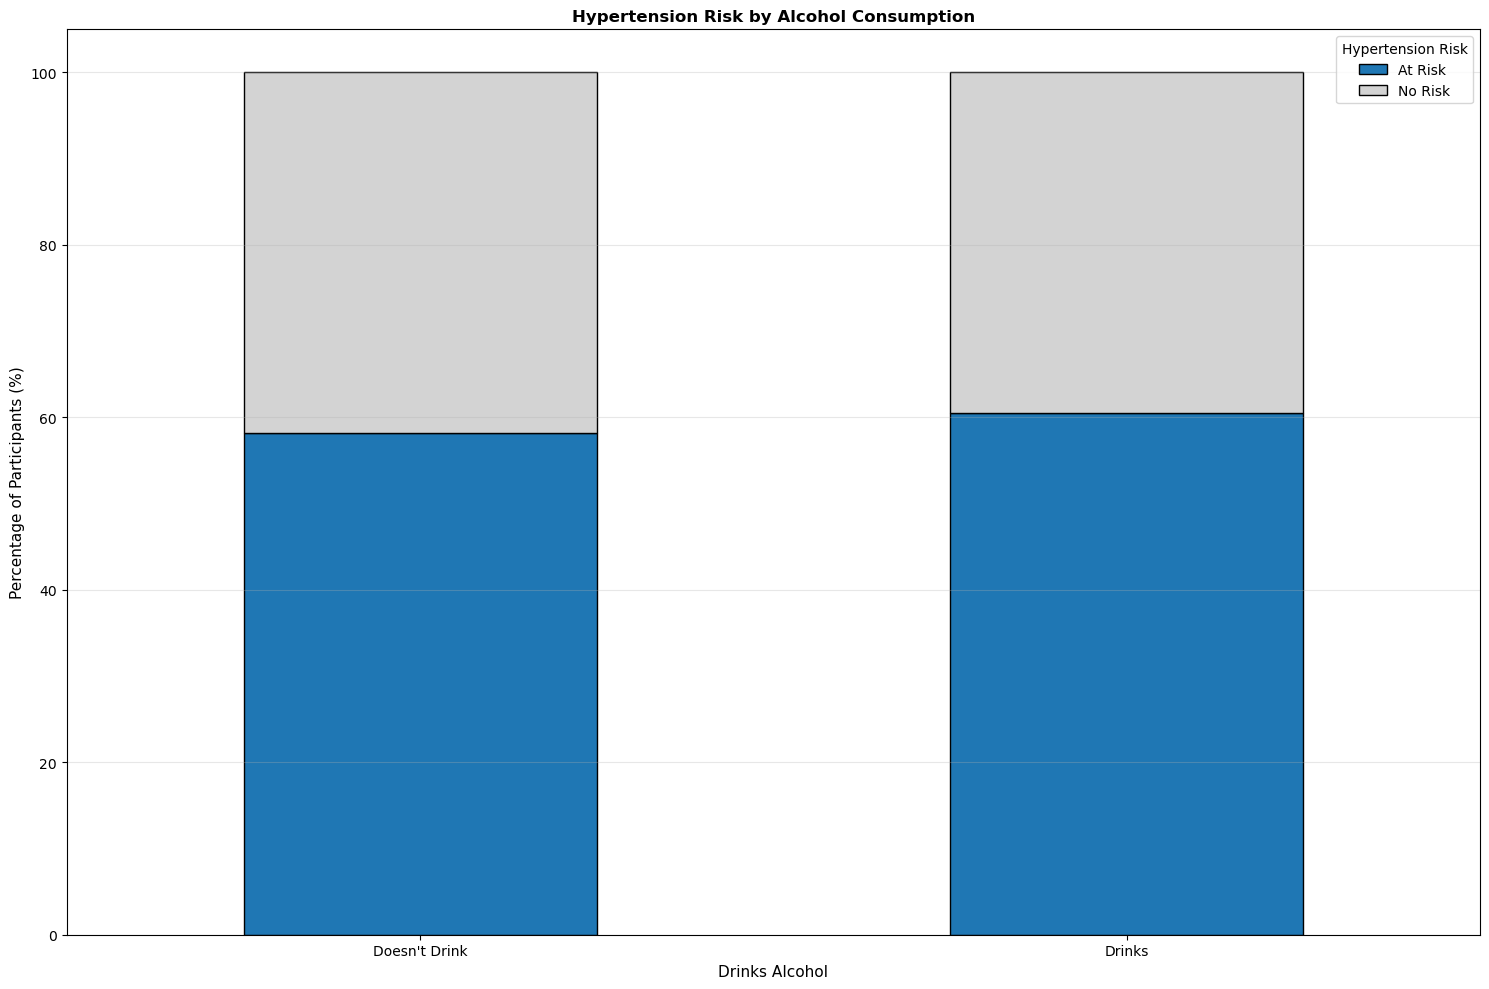


Alcohol Summary:
hypertension_risk          0          1
drinks_alcohol                         
0.0                41.780822  58.219178
1.0                39.462209  60.537791

Alcohol Use Distribution: {1.0: 2752, 0.0: 292}


In [13]:
fig, axes = plt.subplots(figsize=(15, 10))

# Alcohol consumption
alcohol_risk = df.groupby('drinks_alcohol')['hypertension_risk'].value_counts().unstack(fill_value=0)
drinks_pct = alcohol_risk.div(alcohol_risk.sum(axis=1), axis=0) * 100
drinks_pct[[1,0]].plot(kind='bar', stacked=True, ax=axes, edgecolor='black', color=['C0','lightgray'])
axes.set_title('Hypertension Risk by Alcohol Consumption', fontsize=12, 
fontweight='bold')
axes.set_xlabel('Drinks Alcohol', fontsize=11)
axes.set_ylabel('Percentage of Participants (%)', fontsize=11)
axes.set_xticklabels(["Doesn't Drink", "Drinks"], rotation=0)
axes.legend(['At Risk','No Risk'], title='Hypertension Risk', 
frameon=True)
axes.grid(axis='y', alpha=0.3)

# Save figure to the visualizations folder
plt.savefig("../visualizations_pre_imputation/10_alcohol.png", dpi=300, bbox_inches='tight')

# Display the figure
plt.tight_layout()
plt.show()

print("\nAlcohol Summary:")
print(drinks_pct)
print(f"\nAlcohol Use Distribution: {df['drinks_alcohol'].value_counts
().to_dict()}")

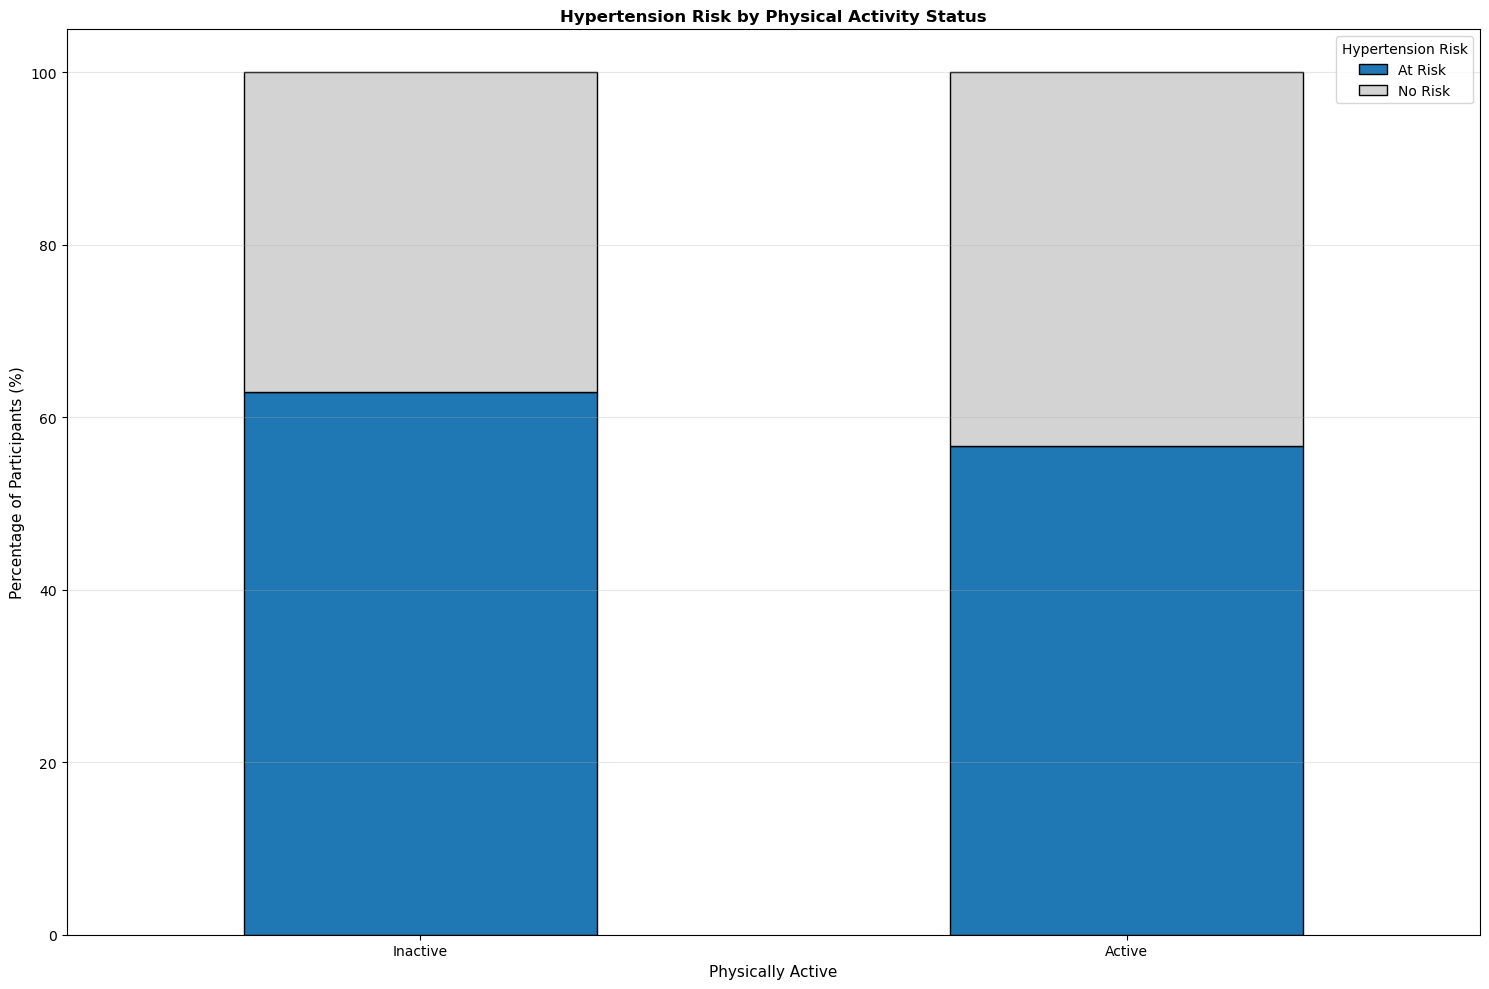


Physical Activity Summary:
hypertension_risk          0          1
physically_active                      
0                  37.064677  62.935323
1                  43.298969  56.701031

Physically Active Distribution: {0: 2010, 1: 1552}


In [14]:
fig, axes = plt.subplots(figsize=(15, 10))

# Physically active status
activity_status = df.groupby('physically_active')['hypertension_risk'].value_counts().unstack(fill_value=0)
activity_pct = activity_status.div(activity_status.sum(axis=1), axis=0) * 100
activity_pct[[1,0]].plot(kind='bar', stacked=True, ax=axes, edgecolor='black', color=['C0', 'lightgray'])
axes.set_title('Hypertension Risk by Physical Activity Status', fontsize=12, fontweight='bold')
axes.set_xlabel('Physically Active', fontsize=11)
axes.set_ylabel('Percentage of Participants (%)', fontsize=11)
axes.set_xticklabels(['Inactive', 'Active'], rotation=0)
axes.legend(['At Risk', 'No Risk'], title='Hypertension Risk', frameon=True)
axes.grid(axis='y', alpha=0.3)

# Save figure to the visualizations folder
plt.savefig("../visualizations_pre_imputation/11_physical_activity_and_lifestyle.png", dpi=300, bbox_inches='tight')

# Display the figure
plt.tight_layout()
plt.show()

print("\nPhysical Activity Summary:")
print(activity_pct)
print(f"\nPhysically Active Distribution: {df['physically_active'].value_counts().to_dict()}")

## 10. Scatter Plots — Key Bivariate Relationships

Scatter plots showing relationships between key variables, colored by hypertension risk.

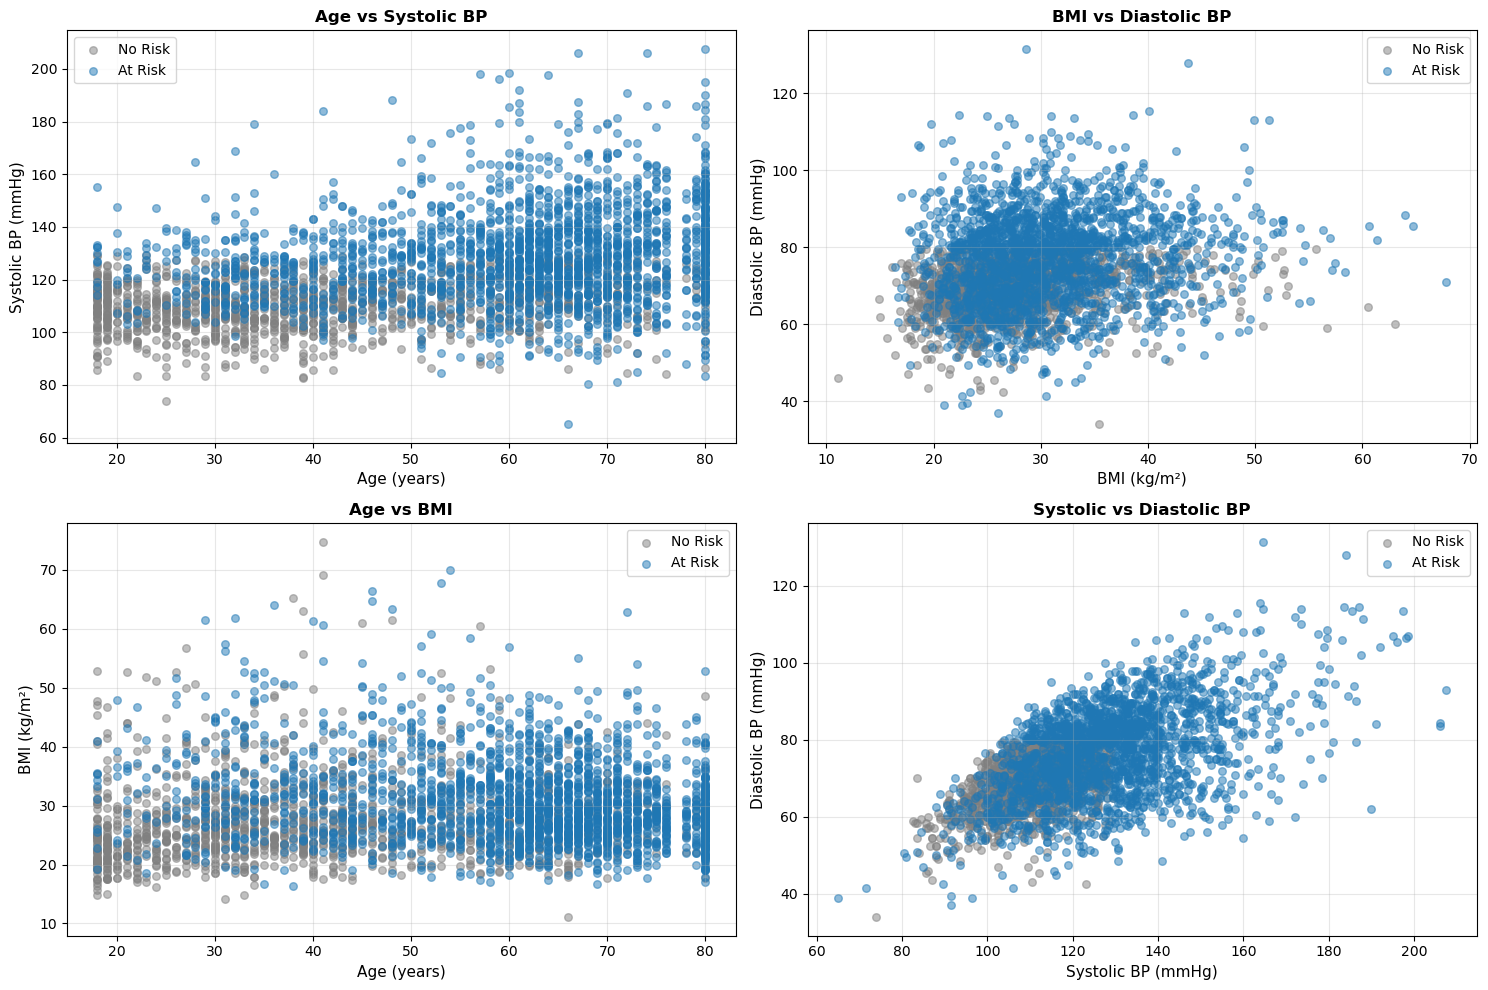

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age vs Systolic BP
for risk in [0, 1]:
    mask = df['hypertension_risk'] == risk
    label = 'At Risk' if risk == 1 else 'No Risk'
    color = "C0" if risk == 1 else "gray"
    axes[0, 0].scatter(df[mask]['age'], df[mask]['systolic_clinical'], alpha=0.5, label=label, color=color, s=30)
axes[0, 0].set_title('Age vs Systolic BP', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age (years)', fontsize=11)
axes[0, 0].set_ylabel('Systolic BP (mmHg)', fontsize=11)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# BMI vs Diastolic BP
for risk in [0, 1]:
    mask = df['hypertension_risk'] == risk
    label = 'At Risk' if risk == 1 else 'No Risk'
    color = "C0" if risk == 1 else "gray"
    axes[0, 1].scatter(df[mask]['bmi'], df[mask]['diastolic_clinical'], alpha=0.5, label=label, color=color, s=30)
axes[0, 1].set_title('BMI vs Diastolic BP', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('BMI (kg/m²)', fontsize=11)
axes[0, 1].set_ylabel('Diastolic BP (mmHg)', fontsize=11)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Age vs BMI
for risk in [0, 1]:
    mask = df['hypertension_risk'] == risk
    label = 'At Risk' if risk == 1 else 'No Risk'
    color = "C0" if risk == 1 else "gray"
    axes[1, 0].scatter(df[mask]['age'], df[mask]['bmi'], alpha=0.5, label=label, color=color, s=30)
axes[1, 0].set_title('Age vs BMI', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Age (years)', fontsize=11)
axes[1, 0].set_ylabel('BMI (kg/m²)', fontsize=11)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Systolic vs Diastolic BP
for risk in [0, 1]:
    mask = df['hypertension_risk'] == risk
    label = 'At Risk' if risk == 1 else 'No Risk'
    color = "C0" if risk == 1 else "gray"
    axes[1, 1].scatter(df[mask]['systolic_clinical'], df[mask]['diastolic_clinical'], alpha=0.5, label=label, color=color, s=30)
axes[1, 1].set_title('Systolic vs Diastolic BP', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Systolic BP (mmHg)', fontsize=11)
axes[1, 1].set_ylabel('Diastolic BP (mmHg)', fontsize=11)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Save figure to the visualizations folder
plt.savefig("../visualizations_pre_imputation/12_scatter_plots.png", dpi=300, bbox_inches='tight')

# Display the figure
plt.tight_layout()
plt.show()

## Summary Statistics and Key Findings

Overview of the dataset and key insights from the exploratory analysis.

In [16]:
print("="*70)
print("NHANES HYPERTENSION RISK — EXPLORATORY DATA ANALYSIS SUMMARY")
print("="*70)

print(f"\n1. DATASET OVERVIEW")
print(f"   • Total participants: {len(df):,}")
print(f"   • Hypertension risk prevalence: {df['hypertension_risk'].mean()*100:.1f}%")
print(f"   • Age range: {df['age'].min():.0f} - {df['age'].max():.0f} years")
print(f"   • Gender: {(df['sex_label']=='Male').sum():,} Male, {(df['sex_label']=='Female').sum():,} Female")

print(f"\n2. BLOOD PRESSURE FINDINGS")
systolic_elevated = ((df['systolic_clinical'] >= 130) | (df['diastolic_clinical'] >= 80)).sum()
print(f"   • With elevated BP (≥130/80): {systolic_elevated:,} ({systolic_elevated/len(df)*100:.1f}%)")
print(f"   • Diagnosed among elevated BP: {(elevated_bp['diagnosed'].sum() / len(elevated_bp) * 100):.1f}%")
print(f"   • Undiagnosed with elevated BP: {((1 - elevated_bp['diagnosed'].sum() / len(elevated_bp)) * 100):.1f}%")

print(f"\n3. DEMOGRAPHIC DISPARITIES")
print(f"   Hypertension Risk by Race/Ethnicity:")
for race, risk in df.groupby('race_ethnicity')['hypertension_risk'].mean().sort_values(ascending=False).items():
    print(f"     • {race:<30} {risk*100:>5.1f}%")

print(f"\n   Hypertension Risk by Gender:")
for gender, risk in df.groupby('sex_label')['hypertension_risk'].mean().items():
    print(f"     • {gender:<30} {risk*100:>5.1f}%")

print(f"\n4. LIFESTYLE FACTORS")
print(f"   Ever Smoker: {(df['ever_smoker']==1).sum()/len(df)*100:.1f}%")
print(f"   Drinks Alcohol: {(df['drinks_alcohol']==1).sum()/len(df)*100:.1f}%")
print(f"   Physically Active: {(df['physically_active']==1).sum()/len(df)*100:.1f}%")

print(f"\n5. HEALTH METRICS (mean ± SD)")
print(f"   BMI:                  {df['bmi'].mean():>6.1f} ± {df['bmi'].std():.1f}")
print(f"   Systolic BP:          {df['systolic_clinical'].mean():>6.1f} ± {df['systolic_clinical'].std():.1f} mmHg")
print(f"   Diastolic BP:         {df['diastolic_clinical'].mean():>6.1f} ± {df['diastolic_clinical'].std():.1f} mmHg")
print(f"   Total Cholesterol:    {df['total_cholesterol_mgdl'].mean():>6.1f} ± {df['total_cholesterol_mgdl'].std():.1f} mg/dL")
print(f"   Fasting Glucose:      {df['fasting_glucose_mgdl'].mean():>6.1f} ± {df['fasting_glucose_mgdl'].std():.1f} mg/dL")

print("\n" + "="*70)

NHANES HYPERTENSION RISK — EXPLORATORY DATA ANALYSIS SUMMARY

1. DATASET OVERVIEW
   • Total participants: 3,562
   • Hypertension risk prevalence: 60.2%
   • Age range: 18 - 80 years
   • Gender: 1,603 Male, 1,959 Female

2. BLOOD PRESSURE FINDINGS
   • With elevated BP (≥130/80): 1,325 (37.2%)
   • Diagnosed among elevated BP: 53.1%
   • Undiagnosed with elevated BP: 46.9%

3. DEMOGRAPHIC DISPARITIES
   Hypertension Risk by Race/Ethnicity:
     • Non-Hispanic Black              65.3%
     • Non-Hispanic White              61.8%
     • Non-Hispanic Asian              60.4%
     • Other Hispanic                  54.0%
     • Mexican American                47.9%

   Hypertension Risk by Gender:
     • Female                          56.0%
     • Male                            65.3%

4. LIFESTYLE FACTORS
   Ever Smoker: 38.6%
   Drinks Alcohol: 77.3%
   Physically Active: 43.6%

5. HEALTH METRICS (mean ± SD)
   BMI:                    29.6 ± 7.4
   Systolic BP:           121.9 ± 17.7 m